# 02 - EDA & Preprocessing
## Exploratory Data Analysis (2b)

У цьому notebook ми:
- Проаналізуємо статистику даних
- Побудуємо візуалізації
- Дослідимо розподіл міток
- Проаналізуємо довжину текстів

In [3]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_dataset
from src.eda import (
    get_basic_stats,
    plot_label_distribution,
    plot_text_length_distribution,
    generate_summary_report
)
from src.config import PROCESSED_DATA_PATH

%matplotlib inline

## 1. Завантаження обробленних даних

In [5]:
# Завантажуємо оброблені дані з попереднього notebook
df = pd.read_csv(PROCESSED_DATA_PATH / 'cleaned_data.csv')
print(f"Завантажено {len(df)} записів")
df.head()

Завантажено 274 записів


,text,label,lang,source,link,cleaned_text,processed_text
0,оборона всу в донецкой области осталась без сн...,фейк,rus,Facebook,https://www.facebook.com/permalink.php?story_f...,the financial times ft,financial times ft
1,flash colonel macgregor la contreattaque russe...,правда,fre,Facebook,https://www.facebook.com/watch/?v=826773688331...,flash colonel macgregor la contreattaque russe...,flash colonel macgregor la contreattaque russe...
2,wer kontrolliert die algorithmen die unser leb...,фейк,ger,Facebook,https://www.facebook.com/Wissenschaftswelle/po...,wer kontrolliert die algorithmen die unser leb...,wer kontrolliert die algorithmen die unser leb...
3,quick update from ukraine including some stuff...,правда,eng,Facebook,https://www.facebook.com/TenbyPowellKiwiK.A.R....,quick update from ukraine including some stuff...,quick update ukraine including stuff rugby fir...
4,reel,фейк,ger,Facebook,https://www.facebook.com/reel/6319655381423078,reel,reel


## 2. Базова статистика

In [6]:
# Отримаємо базову статистику
stats = get_basic_stats(df)

print("Основна інформація:")
print(f"Всього зразків: {stats['total_samples']}")
print(f"Колонки: {stats['columns']}")
print(f"\nТипи даних:")
for col, dtype in stats['dtypes'].items():
    print(f"  {col}: {dtype}")

Основна інформація:
Всього зразків: 274
Колонки: ['text', 'label', 'lang', 'source', 'link', 'cleaned_text', 'processed_text']

Типи даних:
  text: object
  label: object
  lang: object
  source: object
  link: object
  cleaned_text: object
  processed_text: object


In [7]:
# Описова статистика
df.describe()

,text,label,lang,source,link,cleaned_text,processed_text
count,274,274,270,272,274,274,274
unique,274,2,8,59,263,237,236
top,оборона всу в донецкой области осталась без сн...,правда,ukr,X,https://www.facebook.com/yurishvets303/posts/p...,telegram,telegram
freq,1,162,156,40,5,11,11


## 3. Розподіл міток

Saved plot to c:\навчання\третій курс\2 семестр 3 курс\Машинне навчання\КУРСОВА\ДОБРА КУРСОВА\notebooks\..\outputs\label_distribution.png


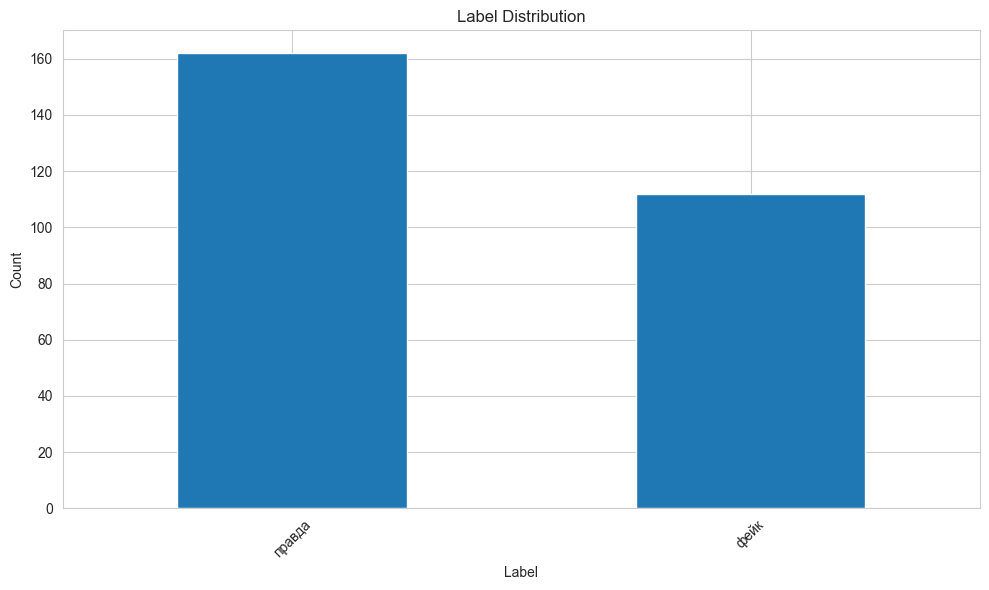

In [8]:
# Побудуємо розподіл міток
plot_label_distribution(df, label_column='label', save=True)

In [9]:
# Відсоткове співвідношення
label_counts = df['label'].value_counts()
label_percentages = (label_counts / len(df) * 100).round(2)

print("Розподіл міток:")
for label, count in label_counts.items():
    print(f"  {label}: {count} ({label_percentages[label]}%)")

Розподіл міток:
  правда: 162 (59.12%)
  фейк: 112 (40.88%)


## 4. Аналіз довжини текстів

Saved plot to c:\навчання\третій курс\2 семестр 3 курс\Машинне навчання\КУРСОВА\ДОБРА КУРСОВА\notebooks\..\outputs\text_length_distribution.png


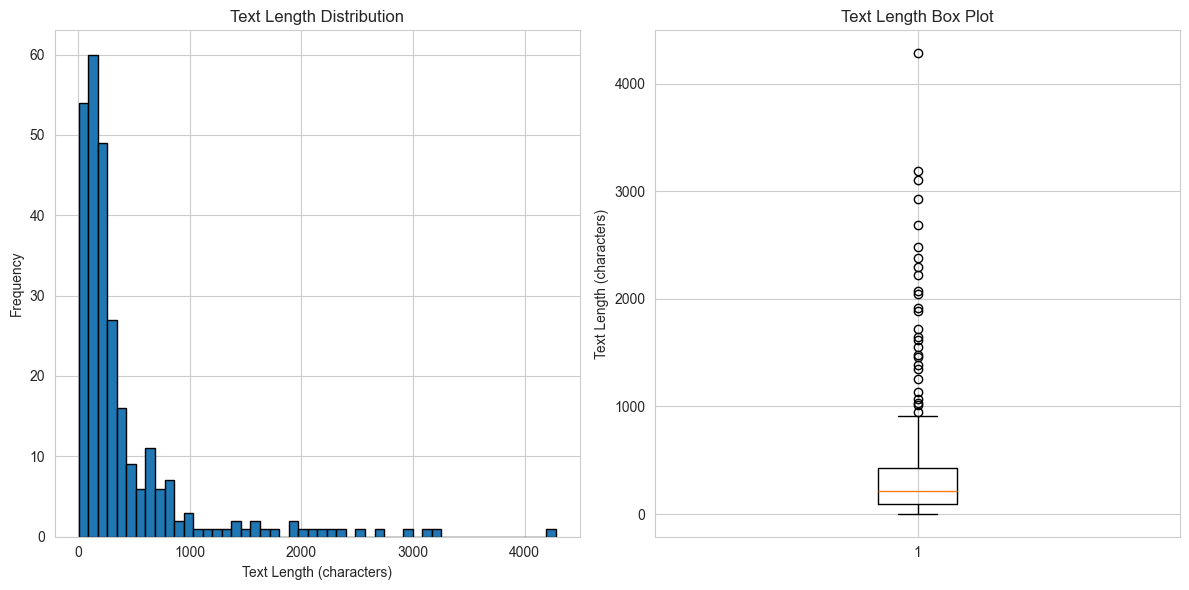

In [10]:
# Аналізуємо довжину оригінальних текстів
plot_text_length_distribution(df, text_column='text', save=True)

In [11]:
# Статистика довжини текстів
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("Статистика довжини текстів (символи):")
print(df['text_length'].describe())

print("\nСтатистика кількості слів:")
print(df['word_count'].describe())

Статистика довжини текстів (символи):
count     274.000000
mean      419.372263
std       592.187891
min         4.000000
25%        98.250000
50%       216.000000
75%       424.500000
max      4280.000000
Name: text_length, dtype: float64

Статистика кількості слів:
count    274.000000
mean      61.956204
std       87.938029
min        1.000000
25%       15.000000
50%       32.000000
75%       62.750000
max      600.000000
Name: word_count, dtype: float64


## 5. Порівняння довжини для різних міток

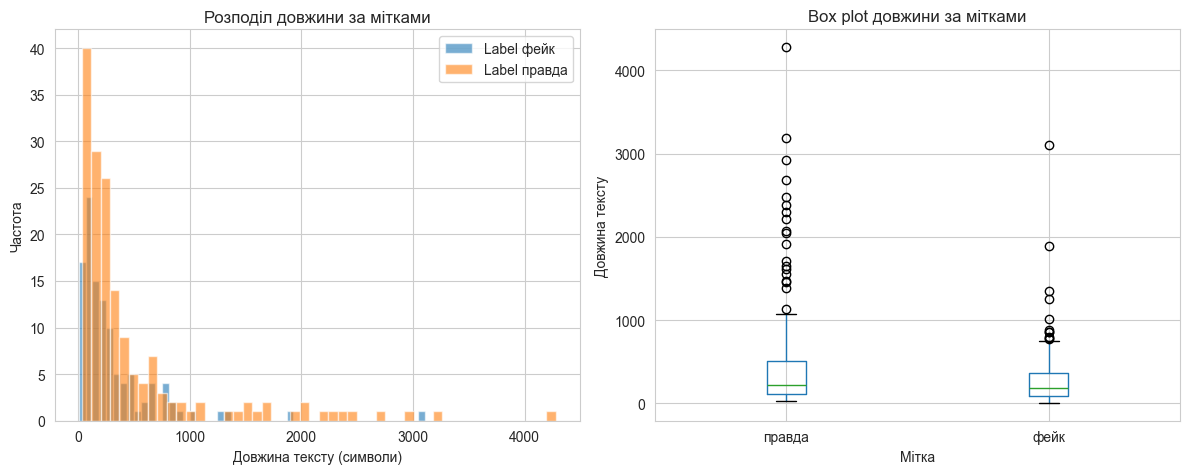

In [12]:
# Порівняємо довжину текстів для різних міток
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for label in df['label'].unique():
    subset = df[df['label'] == label]['text_length']
    plt.hist(subset, alpha=0.6, label=f'Label {label}', bins=50)
plt.xlabel('Довжина тексту (символи)')
plt.ylabel('Частота')
plt.legend()
plt.title('Розподіл довжини за мітками')

plt.subplot(1, 2, 2)
df.boxplot(column='text_length', by='label', ax=plt.gca())
plt.xlabel('Мітка')
plt.ylabel('Довжина тексту')
plt.title('Box plot довжини за мітками')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 6. Загальний звіт

In [13]:
# Згенеруємо звіт
report = generate_summary_report(df, label_column='label')
print(report)


    === Dataset Summary Report ===
    
    Total samples: 274
    Total features: 9
    
    Label distribution:
    label
правда    162
фейк      112
    
    Missing values:
    text              0
label             0
lang              4
source            2
link              0
cleaned_text      0
processed_text    0
text_length       0
word_count        0
    
    


## Висновки

✅ Виконано exploratory data analysis
✅ Проаналізовано розподіл міток
✅ Досліджено довжину та характеристики текстів
✅ Створено візуалізації для подальшого аналізу